In [2]:
%cd "/content/drive/MyDrive/Colab Notebooks/cv practice/face_seg"

/content/drive/MyDrive/Colab Notebooks/cv practice/face_seg


In [3]:
!dir

person_seg_run	Untitled0.ipynb  yolo26n.pt  yolov8n-seg.pt


In [4]:
!pip install ultralytics

In [5]:
# Download latest version
path = kagglehub.dataset_download("tapakah68/supervisely-filtered-segmentation-person-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'supervisely-filtered-segmentation-person-dataset' dataset.
Path to dataset files: /kaggle/input/supervisely-filtered-segmentation-person-dataset


In [6]:
src = path
dst = "/content/dataset"

shutil.copytree(src, dst)

print("Dataset moved to:", dst)

Dataset moved to: /content/dataset


In [7]:
base_path = "/content/dataset/supervisely_person_clean_2667_img/supervisely_person_clean_2667_img"

for root, dirs, files in os.walk(base_path):
    print(f"\n📁 {root}")
    print(f"Subfolders: {dirs}")
    print(f"Files (first 10): {files[:10]}")


📁 /content/dataset/supervisely_person_clean_2667_img/supervisely_person_clean_2667_img
Subfolders: ['masks', 'collage', 'images']
Files (first 10): []

📁 /content/dataset/supervisely_person_clean_2667_img/supervisely_person_clean_2667_img/masks
Subfolders: []
Files (first 10): ['ds7_pexels-photo-843563.png', 'ds6_pexels-photo-245388.png', 'ds6_pexels-photo-769036_U1QCVdiZOa.png', 'ds2_pexels-photo-221342.png', 'ds8_pexels-photo-822404.png', 'ds8_pexels-photo-54203.png', 'ds2_pexels-photo-326546.png', 'ds7_man-holiday-people-face.png', 'ds1_pexels-photo-340566.png', 'ds11_child-girl-laugh-cheerful-160842.png']

📁 /content/dataset/supervisely_person_clean_2667_img/supervisely_person_clean_2667_img/collage
Subfolders: []
Files (first 10): ['ds6_attractive-beautiful-body-smiling-41244.jpg', 'ds6_beautiful-face-female-girl-70354.jpg', 'ds8_color-cute-face-female-87470.jpg', 'ds12_pexels-photo-885207.jpg', 'ds8_pexels-photo-822404.jpg', 'ds4_pexels-photo-775279.jpg', 'ds7_pexels-photo-27459

In [8]:
total_files = 0
for _, _, files in os.walk(base_path):
    total_files += len(files)

print("Total files:", total_files)

Total files: 8001


In [9]:
exts = []

for _, _, files in os.walk(base_path):
    for f in files:
        ext = f.split('.')[-1]
        exts.append(ext)

print(Counter(exts))

Counter({'png': 5334, 'jpg': 2667})


(np.float64(-0.5), np.float64(1599.5), np.float64(2165.5), np.float64(-0.5))

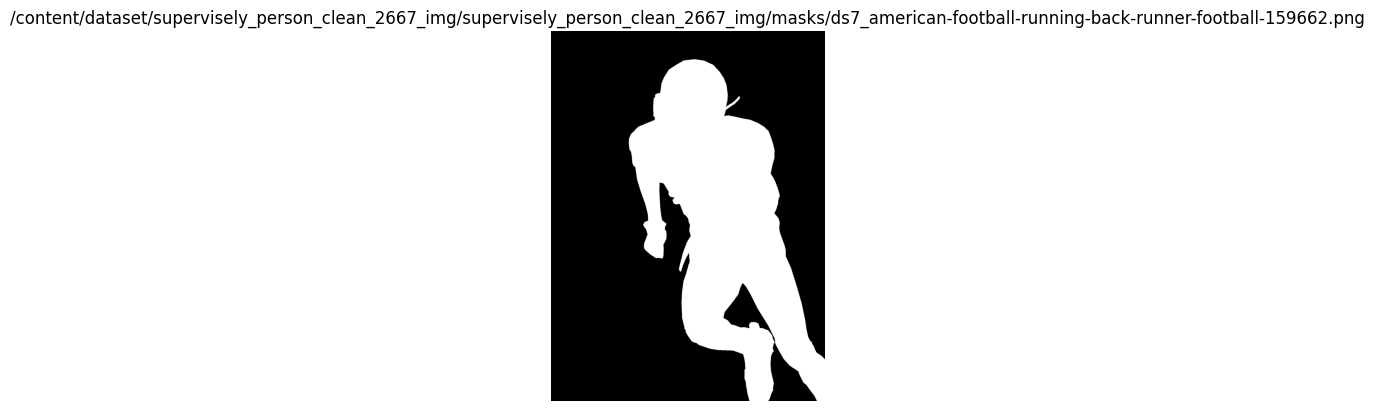

In [10]:
# get random file
all_files = []
for root, _, files in os.walk(base_path):
    for f in files:
        all_files.append(os.path.join(root, f))

sample = random.choice(all_files)

img = cv2.imread(sample)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.title(sample)
plt.axis("off")

In [11]:
base_path = "/content/dataset/supervisely_person_clean_2667_img/supervisely_person_clean_2667_img"

img_dir = os.path.join(base_path, "images")
mask_dir = os.path.join(base_path, "masks")

In [12]:
mask_sample = random.choice(os.listdir(mask_dir))
mask = cv2.imread(os.path.join(mask_dir, mask_sample), 0)

print("Unique mask values:", np.unique(mask))

Unique mask values: [  0 255]


In [22]:
import os

base_path = "/content/dataset/supervisely_person_clean_2667_img/supervisely_person_clean_2667_img"

img_dir = os.path.join(base_path, "images")
mask_dir = os.path.join(base_path, "masks")

out_img_dir = "/content/dataset_yolo/images"
out_lbl_dir = "/content/dataset_yolo/labels"

os.makedirs(out_img_dir, exist_ok=True)
os.makedirs(out_lbl_dir, exist_ok=True)

In [23]:
import cv2
import numpy as np

def mask_to_yolo_seg(mask_path, img_path, label_path):
    mask = cv2.imread(mask_path, 0)

    h, w = mask.shape

    # binary mask
    _, thresh = cv2.threshold(mask, 127, 255, 0)

    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    with open(label_path, "w") as f:
        for cnt in contours:
            if len(cnt) < 3:
                continue

            cnt = cnt.squeeze()

            # normalize points
            points = []
            for x, y in cnt:
                points.append(x / w)
                points.append(y / h)

            # class 0 = person
            line = "0 " + " ".join(map(str, points))
            f.write(line + "\n")

In [24]:
images = os.listdir(img_dir)

for img_name in images:
    img_path = os.path.join(img_dir, img_name)
    mask_path = os.path.join(mask_dir, img_name)

    if not os.path.exists(mask_path):
        continue

    # copy image
    cv2.imwrite(os.path.join(out_img_dir, img_name), cv2.imread(img_path))

    # create label
    label_name = img_name.replace(".png", ".txt")
    label_path = os.path.join(out_lbl_dir, label_name)

    mask_to_yolo_seg(mask_path, img_path, label_path)

print("Conversion done.")

Conversion done.


In [26]:
data_yaml = """
path: /content/dataset_yolo
train: images
val: images

names:
  0: person
"""

with open("/content/dataset_yolo/data.yaml", "w") as f:
    f.write(data_yaml)

In [5]:
save_dir = "/content/drive/MyDrive/Colab Notebooks/cv practice/face_seg"

In [28]:
shutil.rmtree("/content/drive/MyDrive/Colab Notebooks/cv practice/face_seg/person_seg_run")

In [6]:
from ultralytics import YOLO

model = YOLO("yolov8n-seg.pt")

model.train(
    data="/content/dataset_yolo/data.yaml",
    epochs=50,
    imgsz=640,

    device=0,              # FORCE GPU
    workers=4,             # Colab-safe (don’t overpush)
    batch=16,              # increase if GPU allows (T4 can handle 12–16)
    amp=True,              # mixed precision = faster + less VRAM
    project=save_dir,      # save inside Drive
    name="person_seg_run"
)

Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset_yolo/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=person_seg_run2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, 

KeyboardInterrupt: 

In [23]:
import cv2
from matplotlib import pyplot as plt
import numpy as np

In [8]:
# Replace with your model path
model = YOLO('/content/drive/MyDrive/Colab Notebooks/cv practice/face_seg/person_seg_run2/weights/best.pt')

In [19]:
# Replace with your image path
image_path = '/content/photo.jpg'

results = model(image_path)


image 1/1 /content/photo.jpg: 384x640 1 person, 54.1ms
Speed: 2.5ms preprocess, 54.1ms inference, 3.7ms postprocess per image at shape (1, 3, 384, 640)


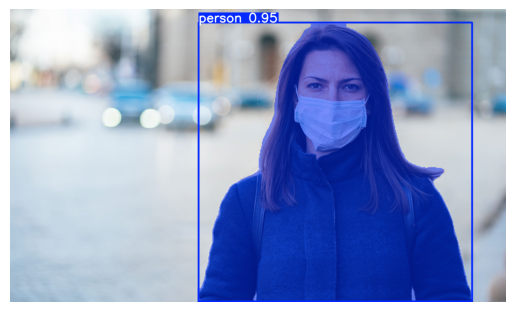

In [20]:
# Plot prediction
res_plotted = results[0].plot()

plt.imshow(cv2.cvtColor(res_plotted, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

In [21]:
results[0].save(filename='/content/drive/MyDrive/Colab Notebooks/cv practice/face_seg/output1.jpg')

'/content/drive/MyDrive/Colab Notebooks/cv practice/face_seg/output1.jpg'

In [28]:
# Load model
model = YOLO("/content/drive/MyDrive/Colab Notebooks/cv practice/face_seg/person_seg_run2/weights/best.pt")   # change path if needed

# Read image
img_path = "/content/photo.jpg"
img = cv2.imread(img_path)

# Run inference
results = model(img_path)

# Get first mask (assuming 1 person)
mask = results[0].masks.data[0].cpu().numpy()

# Convert mask to 0–255
mask = (mask * 255).astype(np.uint8)

# Resize mask to image size
mask = cv2.resize(mask, (img.shape[1], img.shape[0]))

# Create transparent background (RGBA)
b, g, r = cv2.split(img)
alpha = mask
rgba = cv2.merge([b, g, r, alpha])

# Save output
cv2.imwrite("/content/output.png", rgba)

print("Done. Saved as output.png")


image 1/1 /content/photo.jpg: 384x640 1 person, 9.4ms
Speed: 2.2ms preprocess, 9.4ms inference, 3.3ms postprocess per image at shape (1, 3, 384, 640)
Done. Saved as output.png
